
# V4a.2 — Scale calibration для Logistic Preference Model

Цель ноутбука: проверить, можно ли использовать Logistic Preference Model не как прямую замену `heuristic update`, а как источник направления предпочтений с отдельной калибровкой масштаба.

В V4a.1 модель показала высокий `cosine_to_target`, но хуже `final_distance`. Это означает, что она хорошо восстанавливает направление target, но хуже выбирает масштаб preference vector. Здесь сравниваются несколько вариантов финального вектора:

- `Heuristic update` — текущий baseline;
- `Raw Preference Model` — сырой `z_pref` модели;
- `Norm-calibrated PM` — направление модели + норма heuristic state;
- `Train-scale PM` — направление модели + масштаб, подобранный по train log loss;
- `Blend 70% heuristic + 30% PM`;
- `Blend 50% heuristic + 50% PM`.


In [1]:

from personalization.plotting import use_article_style
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from personalization.synthetic_dataset import load_synthetic_users_dataset
from personalization.preference_model_calibration import (
    CALIBRATION_DISPLAY_NAMES,
    run_preference_model_calibration_batch_v4a2,
    summarize_calibration_by_target_mode,
    summarize_calibration_heldout_by_source,
    save_v4a2_outputs,
)
use_article_style()


In [2]:

DATASET_PATH = ROOT / "outputs" / "datasets" / "synthetic_users_v21.csv"
OUTPUT_METRICS_DIR = ROOT / "outputs" / "metrics"
OUTPUT_FIGURES_DIR = ROOT / "outputs" / "figures"

OUTPUT_METRICS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

dataset = load_synthetic_users_dataset(DATASET_PATH)
print(dataset["target_mode"].value_counts())
dataset.head()


target_mode
random8d       100
semantic4d     100
semantic6d     100
archetype8d    100
Name: count, dtype: int64


,user_id,target_mode,noise_std,z_sub_bass,z_bass,z_lowmid,z_warmth,z_presence,z_clarity,z_air,...,mix_warm,mix_bright,mix_v_shape,mix_mid_forward,mix_soft_dark,mix_detail_focused,mix_basshead,mix_extreme_vshape,mix_club_curve,mix_sparkle_lover
0,0,random8d,0.05,0.243774,-0.831987,0.600361,0.752452,-1.560828,-1.041744,0.102272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,random8d,0.05,0.295001,-0.767106,0.702760,-0.039941,-0.147890,-0.544744,0.978033,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,random8d,0.05,-0.409794,-0.651018,0.492784,0.903178,-0.091158,-0.672125,-0.659585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,random8d,0.05,0.543131,0.054063,0.231296,0.505031,-1.165725,-0.255737,-0.376298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,random8d,0.05,0.568981,0.634678,-0.278980,-0.369881,0.686381,-0.153043,-1.020549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## Batch experiment

Для каждого synthetic user модель создаётся заново, обучается online на 25 A/B-ответах от `semantic_active_v21`, после чего сравниваются варианты калибровки финального preference vector.


In [3]:

sessions, heldout_pairs, train_steps = run_preference_model_calibration_batch_v4a2(
    dataset=dataset,
    n_steps=25,
    n_heldout_pairs=100,
    pair_strategy="semantic_active_v21",
    step_scale=0.6,
    heuristic_lr=0.25,
    model_lr=0.06,
    model_temperature=0.75,
    model_l2=0.003,
    model_feature_weight="uniform",
)

summary = summarize_calibration_by_target_mode(sessions)
heldout_by_source = summarize_calibration_heldout_by_source(heldout_pairs)

save_v4a2_outputs(
    sessions=sessions,
    heldout_pairs=heldout_pairs,
    train_steps=train_steps,
    summary=summary,
    source_summary=heldout_by_source,
    output_dir=OUTPUT_METRICS_DIR,
    prefix="notebook_v4a2_preference_model_calibration",
)

summary.head(20)


,target_mode,method,method_display,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_cosine_to_target,mean_vector_norm,mean_train_log_loss,mean_heldout_accuracy,mean_heldout_log_loss,mean_heldout_confidence
0,archetype8d,blend_50h_50m,Blend 50% heuristic + 50% PM,100,1.102635,0.352551,0.162526,0.920683,1.156775,0.471296,0.6327,0.675953,5.593936e-02
1,archetype8d,blend_70h_30m,Blend 70% heuristic + 30% PM,100,1.102635,0.353827,0.147188,0.911927,1.124635,0.473414,0.6327,0.682011,3.376751e-02
2,archetype8d,heuristic_update,Heuristic update,100,1.102635,0.374691,0.133219,0.893582,1.080509,0.480000,0.4974,0.693148,5.279427e-07
3,archetype8d,norm_calibrated_model,Norm-calibrated PM,100,1.102635,0.347072,0.171199,0.929964,1.080509,0.481737,0.6455,0.669253,6.585796e-02
4,archetype8d,raw_preference_model,Raw Preference Model,100,1.102635,0.531560,0.321433,0.929964,0.634486,0.563715,0.6247,0.679746,1.665881e-01
5,archetype8d,train_scale_model,Train-scale PM,100,1.102635,0.391975,0.215620,0.929924,1.245125,0.473559,0.6327,0.665156,1.093457e-01
6,random8d,blend_50h_50m,Blend 50% heuristic + 50% PM,100,2.212002,1.534701,0.490437,0.690120,1.670431,0.409998,0.5253,0.690758,8.094414e-02
7,random8d,blend_70h_30m,Blend 70% heuristic + 30% PM,100,2.212002,1.523020,0.490006,0.691047,1.617680,0.411163,0.5253,0.690077,4.905418e-02
8,random8d,heuristic_update,Heuristic update,100,2.212002,1.518166,0.488628,0.690129,1.543411,0.419406,0.5076,0.693138,1.238965e-05
9,random8d,norm_calibrated_model,Norm-calibrated PM,100,2.212002,1.549718,0.490313,0.683196,1.543411,0.433237,0.5224,0.689903,9.639222e-02


In [4]:

TARGET_MODE_DISPLAY = {
    "random8d": "Random 8D",
    "semantic4d": "Semantic 4D",
    "semantic6d": "Semantic 6D",
    "archetype8d": "Archetype 8D",
}

METHOD_ORDER = [
    "heuristic_update",
    "raw_preference_model",
    "norm_calibrated_model",
    "train_scale_model",
    "blend_70h_30m",
    "blend_50h_50m",
]

ARTICLE_METHODS = [
    "heuristic_update",
    "raw_preference_model",
    "norm_calibrated_model",
    "train_scale_model",
    "blend_70h_30m",
]

METHOD_COLORS = None


def _prepare_plot_df(summary_df, methods=None):
    df = summary_df.copy()
    if methods is not None:
        df = df[df["method"].isin(methods)].copy()
    df["target_mode_display"] = df["target_mode"].map(TARGET_MODE_DISPLAY).fillna(df["target_mode"])
    df["method"] = pd.Categorical(df["method"], categories=METHOD_ORDER, ordered=True)
    df = df.sort_values(["target_mode", "method"])
    return df


def savefig(name: str):
    path = OUTPUT_FIGURES_DIR / name
    plt.savefig(path, dpi=220, bbox_inches="tight")
    print("saved:", path)



## Сравнение final distance

Главный вопрос: улучшает ли калибровка масштаба итоговое расстояние до скрытого `z_target` по сравнению с raw Preference Model и heuristic update.


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v4a2_final_distance_calibration.png


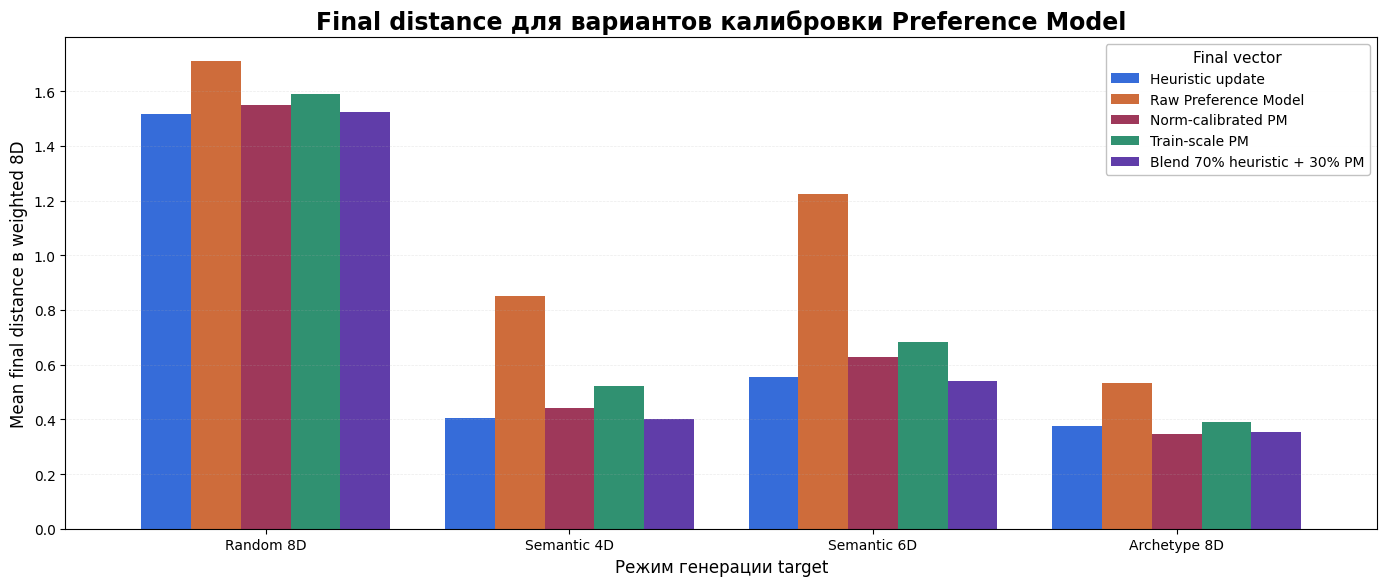

In [5]:

def plot_final_distance_by_target_mode(summary_df, methods=ARTICLE_METHODS):
    df = _prepare_plot_df(summary_df, methods=methods)
    pivot = df.pivot(index="target_mode_display", columns="method_display", values="mean_final_distance")
    # Keep order by original target mode.
    target_order = [TARGET_MODE_DISPLAY[k] for k in ["random8d", "semantic4d", "semantic6d", "archetype8d"]]
    pivot = pivot.reindex([x for x in target_order if x in pivot.index])

    method_names = [CALIBRATION_DISPLAY_NAMES[m] for m in methods]
    pivot = pivot[[m for m in method_names if m in pivot.columns]]

    fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
    pivot.plot(kind="bar", ax=ax, width=0.82)
    ax.set_title("Final distance для вариантов калибровки Preference Model", fontsize=17, fontweight="bold")
    ax.set_xlabel("Режим генерации target")
    ax.set_ylabel("Mean final distance в weighted 8D")
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.legend(title="Final vector", frameon=True, facecolor="white", edgecolor="0.75")
    plt.xticks(rotation=0)
    plt.tight_layout()
    savefig("article_v4a2_final_distance_calibration.png")
    plt.show()

plot_final_distance_by_target_mode(summary)



## Cosine similarity к скрытому target

`cosine_to_target` показывает, совпадает ли направление финального preference vector со скрытым target. Эта метрика отделяет задачу восстановления направления от задачи калибровки масштаба.


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v4a2_cosine_calibration.png


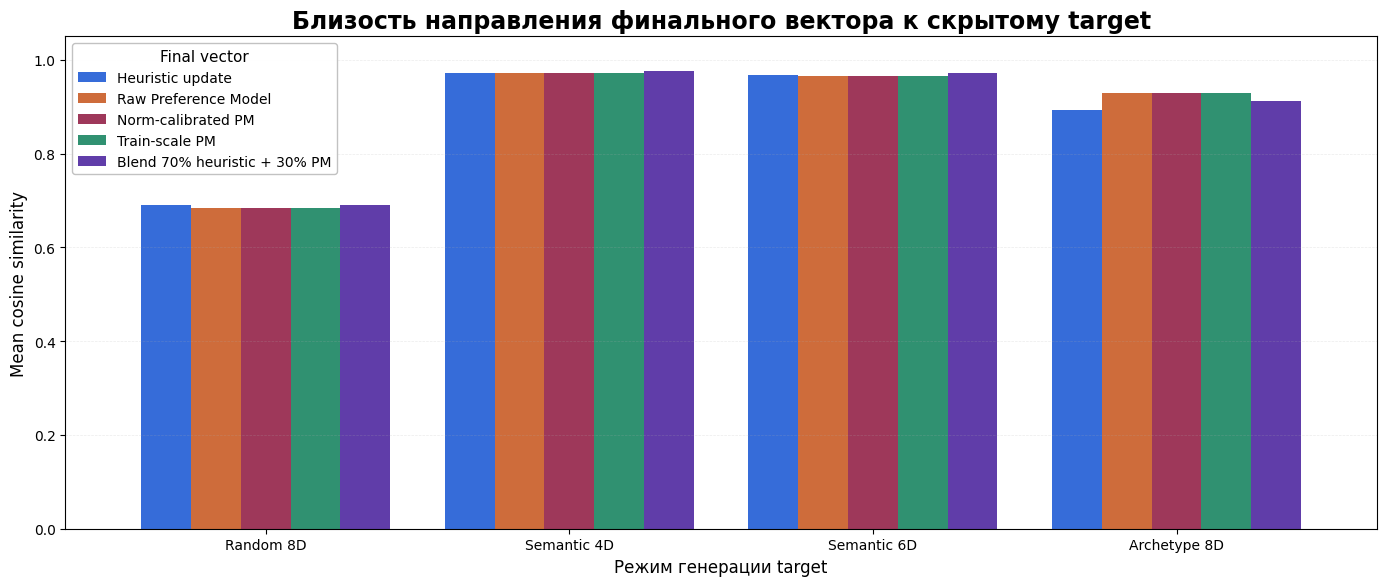

In [6]:

def plot_cosine_by_target_mode(summary_df, methods=ARTICLE_METHODS):
    df = _prepare_plot_df(summary_df, methods=methods)
    pivot = df.pivot(index="target_mode_display", columns="method_display", values="mean_cosine_to_target")
    target_order = [TARGET_MODE_DISPLAY[k] for k in ["random8d", "semantic4d", "semantic6d", "archetype8d"]]
    pivot = pivot.reindex([x for x in target_order if x in pivot.index])
    method_names = [CALIBRATION_DISPLAY_NAMES[m] for m in methods]
    pivot = pivot[[m for m in method_names if m in pivot.columns]]

    fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
    pivot.plot(kind="bar", ax=ax, width=0.82)
    ax.set_title("Близость направления финального вектора к скрытому target", fontsize=17, fontweight="bold")
    ax.set_xlabel("Режим генерации target")
    ax.set_ylabel("Mean cosine similarity")
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.legend(title="Final vector", frameon=True, facecolor="white", edgecolor="0.75")
    plt.xticks(rotation=0)
    plt.tight_layout()
    savefig("article_v4a2_cosine_calibration.png")
    plt.show()

plot_cosine_by_target_mode(summary)



## Held-out accuracy

Held-out пары не использовались при online-обучении. Эта проверка показывает, переносится ли выученное направление на новые A/B-вопросы.


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v4a2_heldout_accuracy_calibration.png


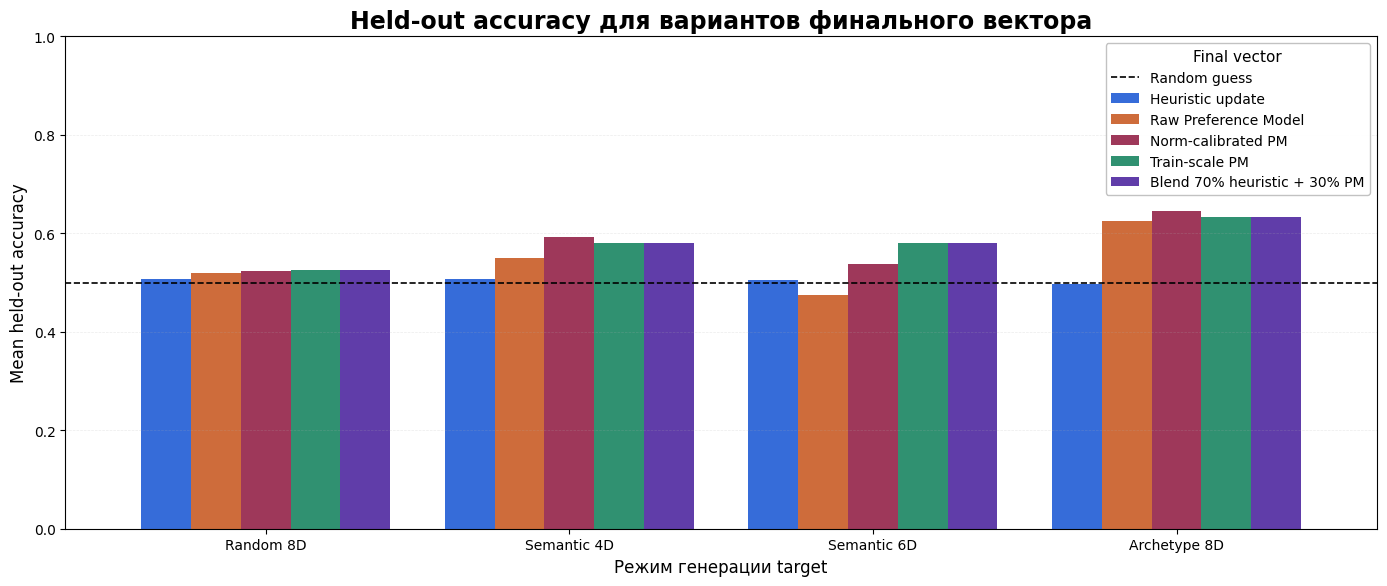

In [7]:

def plot_heldout_accuracy_by_target_mode(summary_df, methods=ARTICLE_METHODS):
    df = _prepare_plot_df(summary_df, methods=methods)
    pivot = df.pivot(index="target_mode_display", columns="method_display", values="mean_heldout_accuracy")
    target_order = [TARGET_MODE_DISPLAY[k] for k in ["random8d", "semantic4d", "semantic6d", "archetype8d"]]
    pivot = pivot.reindex([x for x in target_order if x in pivot.index])
    method_names = [CALIBRATION_DISPLAY_NAMES[m] for m in methods]
    pivot = pivot[[m for m in method_names if m in pivot.columns]]

    fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")
    pivot.plot(kind="bar", ax=ax, width=0.82)
    ax.axhline(0.5, linestyle="--", linewidth=1.2, color="black", label="Random guess")
    ax.set_title("Held-out accuracy для вариантов финального вектора", fontsize=17, fontweight="bold")
    ax.set_xlabel("Режим генерации target")
    ax.set_ylabel("Mean held-out accuracy")
    ax.set_ylim(0, 1.0)
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.legend(title="Final vector", frameon=True, facecolor="white", edgecolor="0.75")
    plt.xticks(rotation=0)
    plt.tight_layout()
    savefig("article_v4a2_heldout_accuracy_calibration.png")
    plt.show()

plot_heldout_accuracy_by_target_mode(summary)



## Фокус на Archetype 8D

`Archetype 8D` — основной реалистичный режим. Ниже сравниваются варианты калибровки именно на нём.


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v4a2_archetype8d_final_distance.png


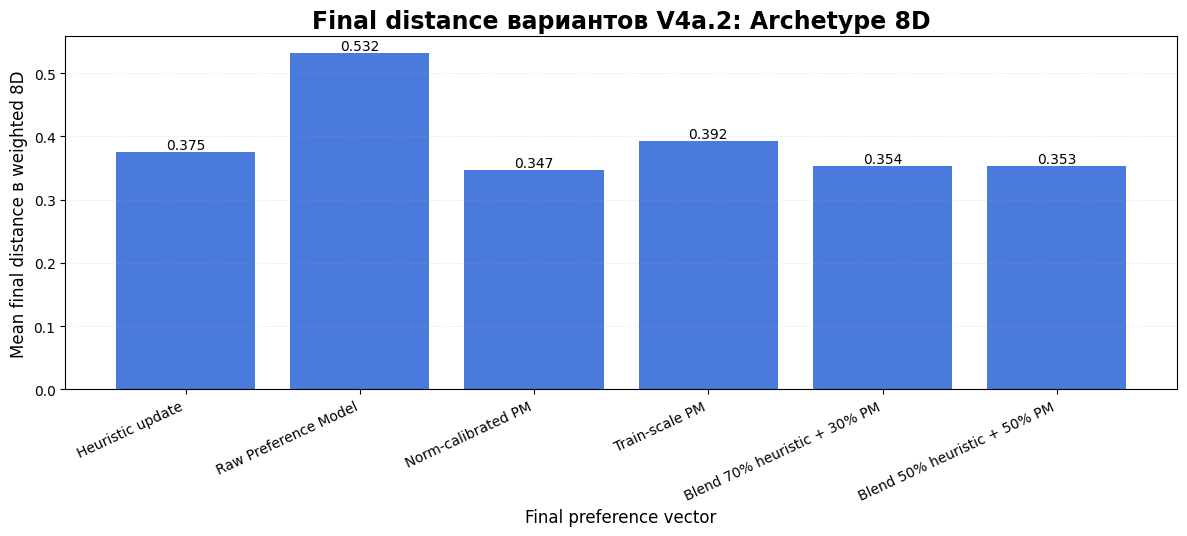

In [8]:

def plot_archetype8d_calibration(summary_df, methods=METHOD_ORDER):
    df = summary_df[(summary_df["target_mode"] == "archetype8d") & (summary_df["method"].isin(methods))].copy()
    df["method"] = pd.Categorical(df["method"], categories=methods, ordered=True)
    df = df.sort_values("method")

    fig, ax = plt.subplots(figsize=(12, 5.5), facecolor="white")
    bars = ax.bar(df["method_display"], df["mean_final_distance"], alpha=0.9)
    ax.set_title("Final distance вариантов V4a.2: Archetype 8D", fontsize=17, fontweight="bold")
    ax.set_xlabel("Final preference vector")
    ax.set_ylabel("Mean final distance в weighted 8D")
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    plt.xticks(rotation=25, ha="right")
    for bar, value in zip(bars, df["mean_final_distance"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.3f}", ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    savefig("article_v4a2_archetype8d_final_distance.png")
    plt.show()

plot_archetype8d_calibration(summary)



## Held-out accuracy по типу новых A/B-вопросов

Сравним, на каких новых вопросах калиброванные векторы лучше предсказывают synthetic user: random, axis или semantic6d.


saved: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v4a2_heldout_by_source_archetype8d.png


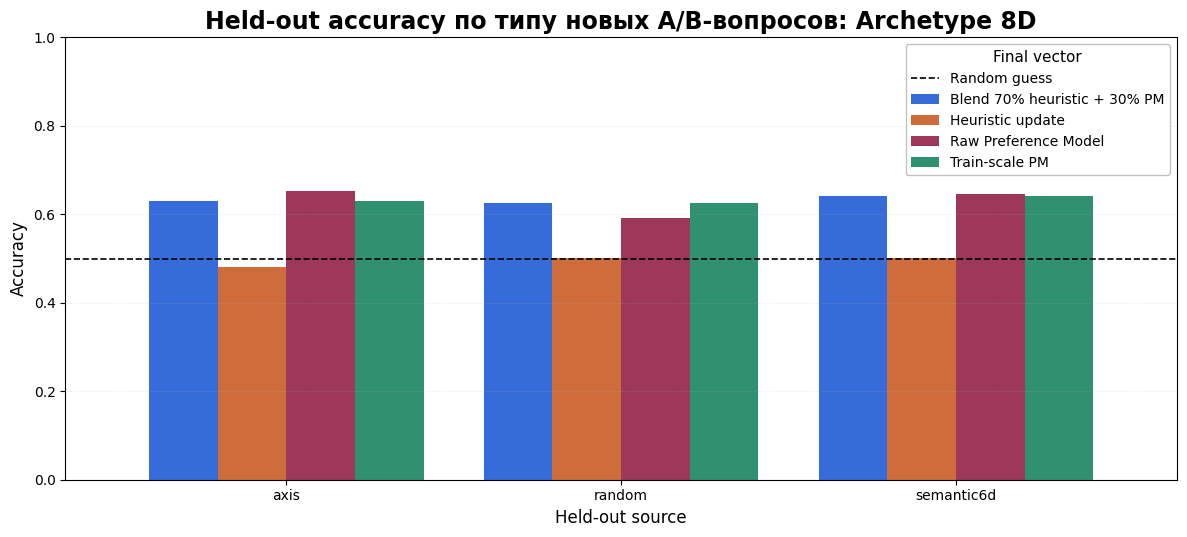

In [9]:

def plot_heldout_by_source(source_summary_df, target_mode="archetype8d", methods=["heuristic_update", "raw_preference_model", "train_scale_model", "blend_70h_30m"]):
    df = source_summary_df[
        (source_summary_df["target_mode"] == target_mode) &
        (source_summary_df["method"].isin(methods))
    ].copy()
    df["method"] = pd.Categorical(df["method"], categories=methods, ordered=True)
    df = df.sort_values(["source", "method"])
    pivot = df.pivot(index="source", columns="method_display", values="accuracy")

    fig, ax = plt.subplots(figsize=(12, 5.5), facecolor="white")
    pivot.plot(kind="bar", ax=ax, width=0.82)
    ax.axhline(0.5, linestyle="--", linewidth=1.2, color="black", label="Random guess")
    ax.set_title("Held-out accuracy по типу новых A/B-вопросов: Archetype 8D", fontsize=17, fontweight="bold")
    ax.set_xlabel("Held-out source")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.0)
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.legend(title="Final vector", frameon=True, facecolor="white", edgecolor="0.75")
    plt.xticks(rotation=0)
    plt.tight_layout()
    savefig("article_v4a2_heldout_by_source_archetype8d.png")
    plt.show()

plot_heldout_by_source(heldout_by_source)



## Итоговые таблицы


In [10]:

summary_pivot = summary.pivot_table(
    index="target_mode",
    columns="method_display",
    values=["mean_final_distance", "mean_cosine_to_target", "mean_heldout_accuracy"],
)
summary_pivot


mean_cosine_to_target                               \
method_display Blend 50% heuristic + 50% PM Blend 70% heuristic + 30% PM   
target_mode                                                                
archetype8d                        0.920683                     0.911927   
random8d                           0.690120                     0.691047   
semantic4d                         0.975722                     0.975276   
semantic6d                         0.971034                     0.971186   

                                                                         \
method_display Heuristic update Norm-calibrated PM Raw Preference Model   
target_mode                                                               
archetype8d            0.893582           0.929964             0.929964   
random8d               0.690129           0.683196             0.683196   
semantic4d             0.971378           0.971319             0.971319   
semantic6d             0.968033           0.964997             0.964997   

                                       mean_final_distance  \
method_display Train-scale PM Blend 50% heuristic + 50% PM   
target_mode                                                  
archetype8d          0.929924                     0.352551   
random8d             0.683834                     1.534701   
semantic4d           0.971319                     0.418344   
semantic6d           0.964801                     0.558869   

                                                              \
method_display Blend 70% heuristic + 30% PM Heuristic update   
target_mode                                                    
archetype8d                        0.353827         0.374691   
random8d                           1.523020         1.518166   
semantic4d                         0.400412         0.404110   
semantic6d                         0.539944         0.553327   

                                                                       \
method_display Norm-calibrated PM Raw Preference Model Train-scale PM   
target_mode                                                             
archetype8d              0.347072             0.531560       0.391975   
random8d                 1.549718             1.712102       1.589754   
semantic4d               0.441768             0.850380       0.522241   
semantic6d               0.629677             1.225603       0.681143   

                      mean_heldout_accuracy                               \
method_display Blend 50% heuristic + 50% PM Blend 70% heuristic + 30% PM   
target_mode                                                                
archetype8d                          0.6327                       0.6327   
random8d                             0.5253                       0.5253   
semantic4d                           0.5796                       0.5796   
semantic6d                           0.5802                       0.5803   

                                                                         \
method_display Heuristic update Norm-calibrated PM Raw Preference Model   
target_mode                                                               
archetype8d              0.4974             0.6455               0.6247   
random8d                 0.5076             0.5224               0.5187   
semantic4d               0.5071             0.5933               0.5496   
semantic6d               0.5057             0.5373               0.4737   

                               
method_display Train-scale PM  
target_mode                    
archetype8d            0.6327  
random8d               0.5253  
semantic4d             0.5796  
semantic6d             0.5801

## Вывод по V4a.2 scale calibration

Эксперимент V4a.2 показал, что Logistic Preference Model не следует использовать напрямую как итоговый preference vector: raw-вектор модели имеет правильное направление, но плохо калибрует масштаб, из-за чего final distance оказывается хуже, чем у эвристического update.

После калибровки масштаба результат существенно улучшается. На основном realistic-режиме `Archetype 8D` вариант `Norm-calibrated PM` достиг mean final distance около `0.347`, тогда как эвристический update показал около `0.375`, а raw Preference Model — около `0.532`. Кроме того, `Norm-calibrated PM` имеет более высокую cosine similarity к скрытому target и held-out accuracy около `0.646`, что заметно выше случайного уровня.

Для режимов `Semantic 4D` и `Semantic 6D` наиболее стабильным оказался blend-подход, в котором итоговый вектор строится как смесь heuristic state и направления Preference Model. Это показывает, что Preference Model полезна как дополнительный направляющий сигнал, но её лучше интегрировать осторожно, не заменяя полностью эвристический state.

Таким образом, V4a.2 подтверждает пользу Preference Model в контуре персонализации: модель извлекает направление скрытых предпочтений из A/B-истории, а после scale calibration это направление может улучшать итоговый preference vector. Дальнейшее развитие может идти в сторону model-based Pair Generator, где Preference Model будет использоваться не только для финального вектора, но и для выбора наиболее информативных A/B-вопросов.